In [1]:
# CELL 1 — Run this first
# These are the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
roc_auc_score, RocCurveDisplay,
ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# CELL 2 — Load transactions data
# Change the path if your CSV is in a different folder
print("Loading transactions... this may take 2-5 minutes for large file")
# Load only 500,000 rows to keep it fast
# If your PC has 16GB+ RAM you can remove nrows to load all data
df = pd.read_csv(
r"C:\GlobalFashion\data\transactions.csv",
nrows=500000,
low_memory=False
)
print(f"Loaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(df.head(3))

Loading transactions... this may take 2-5 minutes for large file
Loaded 500,000 rows
Columns: ['Invoice ID', 'Line', 'Customer ID', 'Product ID', 'Size', 'Color', 'Unit Price', 'Quantity', 'Date', 'Discount', 'Line Total', 'Store ID', 'Employee ID', 'Currency', 'Currency Symbol', 'SKU', 'Transaction Type', 'Payment Method', 'Invoice Total']
            Invoice ID  Line  Customer ID  Product ID Size    Color  \
0  INV-US-001-03558761     1        47162         485    M      NaN   
1  INV-US-001-03558761     2        47162        2779    G      NaN   
2  INV-US-001-03558761     3        47162          64    M  NEUTRAL   

   Unit Price  Quantity            Date  Discount  Line Total  Store ID  \
0        80.5         1  01-01-23 15:42       0.0        80.5         1   
1        31.5         1  01-01-23 15:42       0.4        18.9         1   
2        45.5         1  01-01-23 15:42       0.4        27.3         1   

   Employee ID Currency Currency Symbol               SKU Transaction T

In [3]:
# CELL 3 — Load products data
products = pd.read_csv(r"C:\GlobalFashion\data\products.csv",
low_memory=False)
stores = pd.read_csv(r"C:\GlobalFashion\data\stores.csv")
print("Products loaded:", products.shape)
print("Stores loaded:", stores.shape)
print(products.columns.tolist())

Products loaded: (17940, 12)
Stores loaded: (35, 8)
['Product ID', 'Category', 'Sub Category', 'Description PT', 'Description DE', 'Description FR', 'Description ES', 'Description EN', 'Description ZH', 'Color', 'Sizes', 'Production Cost']


In [4]:
# CELL 4 — Create target column
# is_return = 1 means Return, 0 means Sale
# First check your transaction type column name
print("Transaction type values:")
# Try each line below until one works:
# print(df["Transaction Type"].value_counts())
# print(df["transaction_type"].value_counts())
# Use the correct column name for your data:
# If column is "Transaction Type":
df["is_return"] = (df["Transaction Type"] == "Return").astype(int)
# If column is "transaction_type":
# df["is_return"] = (df["transaction_type"] == "Return").astype(int)
print("\nTarget column created!")
print(df["is_return"].value_counts())
print(f"Return rate: {df['is_return'].mean()*100:.1f}%")

Transaction type values:

Target column created!
is_return
0    473569
1     26431
Name: count, dtype: int64
Return rate: 5.3%


In [5]:
# CELL 5 — Add product category to transactions
# Check column names first
print("Transaction columns:", df.columns.tolist())
print("Product columns:", products.columns.tolist())
# Merge based on product ID column
# Adjust column names if needed
df = df.merge(
products[["Product ID", "Category", "Sub Category",
"Production Cost"]],
left_on="Product ID",
right_on="Product ID",
how="left"
)
# Merge store country
df = df.merge(
stores[["Store ID", "Country"]],
left_on="Store ID",
right_on="Store ID",
how="left"
)
df.rename(columns={"Country": "Store Country"}, inplace=True)

print("\nMerge done!")
print(f"Rows: {len(df):,}")
print(df[["Category", "Store Country"]].head(3))

Transaction columns: ['Invoice ID', 'Line', 'Customer ID', 'Product ID', 'Size', 'Color', 'Unit Price', 'Quantity', 'Date', 'Discount', 'Line Total', 'Store ID', 'Employee ID', 'Currency', 'Currency Symbol', 'SKU', 'Transaction Type', 'Payment Method', 'Invoice Total', 'is_return']
Product columns: ['Product ID', 'Category', 'Sub Category', 'Description PT', 'Description DE', 'Description FR', 'Description ES', 'Description EN', 'Description ZH', 'Color', 'Sizes', 'Production Cost']

Merge done!
Rows: 500,000
    Category  Store Country
0  Masculine  United States
1   Children  United States
2  Masculine  United States


In [7]:
# CELL 6 — Choose which columns to use for prediction
# These are the features (inputs) for our model
feature_cols = [
"Unit Price",
"Quantity",
"Discount",
"Category",
"Sub Category",
"Store Country",
"Payment Method",
"Size"
]
# Check all these columns exist
for col in feature_cols:
   if col in df.columns:
       print(f" {col} — OK")
   else:
       print(f" {col} — MISSING! Check column name")

 Unit Price — OK
 Quantity — OK
 Discount — OK
 Category — OK
 Sub Category — OK
 Store Country — OK
 Payment Method — OK
 Size — OK


In [9]:
# CELL 7 — Prepare features and target
# Get features and target
X = df[feature_cols].copy()
y = df["is_return"].copy()
# Check for missing values
print("Missing values per column:")
print(X.isnull().sum())
# Fill missing text columns with "Unknown"
text_cols = ["Category", "Sub Category", "Store Country",
"Payment Method", "Size"]
for col in text_cols:
    if col in X.columns:
        X[col] = X[col].fillna("Unknown")
# Fill missing numbers with 0
num_cols = ["Unit Price", "Quantity", "Discount"]
for col in num_cols:
    if col in X.columns:
       X[col] = X[col].fillna(0)
print("\nAfter filling missing values:")
print(X.isnull().sum())

Missing values per column:
Unit Price            0
Quantity              0
Discount              0
Category              0
Sub Category          0
Store Country         0
Payment Method        0
Size              31745
dtype: int64

After filling missing values:
Unit Price        0
Quantity          0
Discount          0
Category          0
Sub Category      0
Store Country     0
Payment Method    0
Size              0
dtype: int64


In [12]:
# CELL 8 — Convert text to numbers
# Machine learning needs numbers, not text
le = LabelEncoder()
for col in text_cols:
    if col in X.columns:
       X[col] = le.fit_transform(X[col].astype(str))
print(f"Encoded: {col}")
print("\nAll text columns converted to numbers!")
print(X.dtypes)
print(X.head(3))

Encoded: Size

All text columns converted to numbers!
Unit Price        float64
Quantity            int64
Discount          float64
Category            int64
Sub Category        int64
Store Country       int64
Payment Method      int64
Size                int64
dtype: object
   Unit Price  Quantity  Discount  Category  Sub Category  Store Country  \
0        80.5         1       0.0         2             5              0   
1        31.5         1       0.4         0            12              0   
2        45.5         1       0.4         2            14              0   

   Payment Method  Size  
0               0     2  
1               0    13  
2               0     2  


In [13]:
# CELL 9 — Split into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y
)
print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")
print(f"\nTraining returns: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Testing returns: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

Training rows: 400,000
Testing rows: 100,000

Training returns: 21,145 (5.3%)
Testing returns: 5,286 (5.3%)


In [14]:
# CELL 10 — Normalize feature values
# This makes all numbers on same scale
# Required for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled successfully!")
print(f"Feature shape: {X_train_scaled.shape}")

Features scaled successfully!
Feature shape: (400000, 8)


In [15]:
# CELL 11 — Train Logistic Regression model
# Simple but powerful linear model
print("Training Logistic Regression...")
lr_model = LogisticRegression(
max_iter=1000,
random_state=42
)
lr_model.fit(X_train_scaled, y_train)
# Make predictions
lr_pred = lr_model.predict(X_test_scaled)
print("\nLogistic Regression — Results:")
print(classification_report(y_test, lr_pred,
target_names=["Sale", "Return"]))
lr_auc = roc_auc_score(y_test,
lr_model.predict_proba(X_test_scaled)[:,1])
print(f"ROC-AUC Score: {lr_auc:.4f}")

Training Logistic Regression...

Logistic Regression — Results:
              precision    recall  f1-score   support

        Sale       0.95      1.00      0.97     94714
      Return       0.00      0.00      0.00      5286

    accuracy                           0.95    100000
   macro avg       0.47      0.50      0.49    100000
weighted avg       0.90      0.95      0.92    100000

ROC-AUC Score: 0.6486


In [16]:
# CELL 12 — Train Random Forest model
# More powerful than Logistic Regression
# May take 2-5 minutes to train
print("Training Random Forest... please wait...")
rf_model = RandomForestClassifier(
n_estimators=100,
max_depth=10,
random_state=42,
n_jobs=-1
)
rf_model.fit(X_train, y_train)
# Make predictions
rf_pred = rf_model.predict(X_test)
print("\nRandom Forest — Results:")
print(classification_report(y_test, rf_pred,
target_names=["Sale", "Return"]))
rf_auc = roc_auc_score(y_test,
rf_model.predict_proba(X_test)[:,1])
print(f"ROC-AUC Score: {rf_auc:.4f}")

Training Random Forest... please wait...

Random Forest — Results:
              precision    recall  f1-score   support

        Sale       0.95      1.00      0.97     94714
      Return       0.00      0.00      0.00      5286

    accuracy                           0.95    100000
   macro avg       0.47      0.50      0.49    100000
weighted avg       0.90      0.95      0.92    100000

ROC-AUC Score: 0.6690


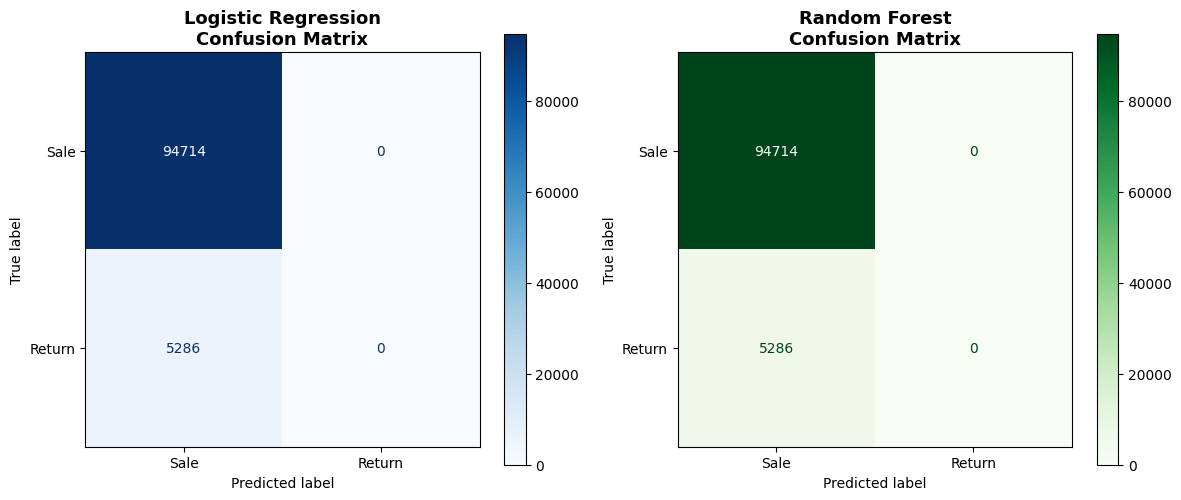

Saved as confusion_matrix.png


In [18]:
#CELL 13 — Plot Confusion Matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
y_test, lr_pred,
display_labels=["Sale", "Return"],
cmap="Blues",
ax=axes[0]
)
axes[0].set_title("Logistic Regression\nConfusion Matrix",
fontsize=13, fontweight="bold")
# Random Forest confusion matrix
ConfusionMatrixDisplay.from_predictions(
y_test, rf_pred,
display_labels=["Sale", "Return"],
cmap="Greens",
ax=axes[1]
)
axes[1].set_title("Random Forest\nConfusion Matrix",
fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150,
bbox_inches="tight")
plt.show()
print("Saved as confusion_matrix.png")

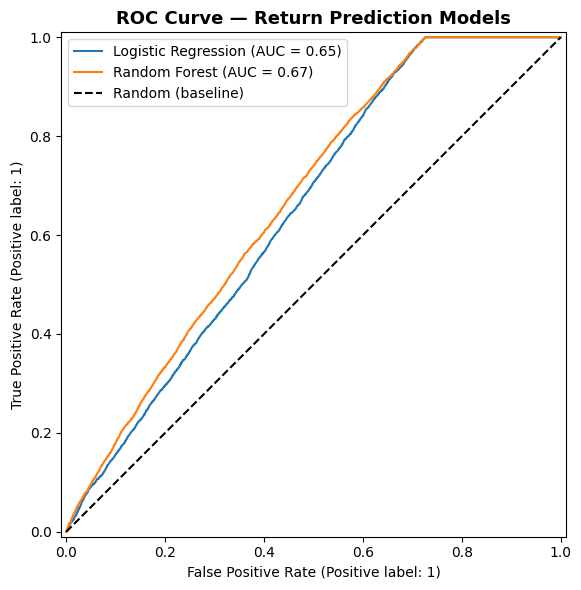

Saved as roc_curve.png


In [19]:
# CELL 14 — Plot ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
# Logistic Regression ROC curve
RocCurveDisplay.from_estimator(
lr_model, X_test_scaled, y_test,
ax=ax, name="Logistic Regression"
)
# Random Forest ROC curve
RocCurveDisplay.from_estimator(
rf_model, X_test, y_test,
ax=ax, name="Random Forest"
)
ax.set_title("ROC Curve — Return Prediction Models",
fontsize=13, fontweight="bold")
ax.plot([0,1],[0,1],"k--", label="Random (baseline)")
ax.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150,
bbox_inches="tight")
plt.show()
print("Saved as roc_curve.png")

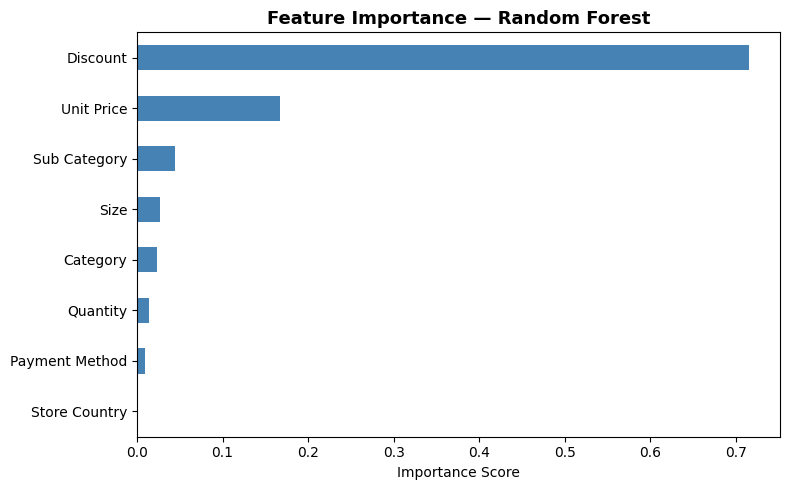

Saved as feature_importance.png


In [20]:
# CELL 15 — Feature Importance Chart
# Shows which features most influence return prediction
importances = pd.Series(
rf_model.feature_importances_,
index=feature_cols
).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax,
color="steelblue")
ax.set_title("Feature Importance — Random Forest",
fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150,
bbox_inches="tight")
plt.show()
print("Saved as feature_importance.png")

In [21]:
# CELL 16 — Print final comparison table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = {
"Model": ["Logistic Regression", "Random Forest"],
"Accuracy": [
accuracy_score(y_test, lr_pred),
accuracy_score(y_test, rf_pred)
],
"Precision": [
precision_score(y_test, lr_pred),
precision_score(y_test, rf_pred)
],
"Recall": [
recall_score(y_test, lr_pred),
recall_score(y_test, rf_pred)
],
"F1 Score": [
f1_score(y_test, lr_pred),
f1_score(y_test, rf_pred)
],
"ROC-AUC": [lr_auc, rf_auc]
}
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print("\n=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))
print("\nBetter model: Random Forest" if rf_auc > lr_auc
else "\nBetter model: Logistic Regression")


=== MODEL COMPARISON ===
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9471        0.0     0.0       0.0   0.6486
      Random Forest    0.9471        0.0     0.0       0.0   0.6690

Better model: Random Forest


In [22]:
# CELL 1 — Import libraries for forecasting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")
print("Libraries loaded!")

Libraries loaded!


In [23]:
# CELL 2 — Load data and check date column
df = pd.read_csv(
r"C:\GlobalFashion\data\transactions.csv",
nrows=500000,
low_memory=False
)
products = pd.read_csv(r"C:\GlobalFashion\data\products.csv")
# Merge category
df = df.merge(
products[["Product ID", "Category"]],
on="Product ID", how="left"
)
# Check date column
print("Date column sample:")
print(df["Date"].head(10).tolist())
print(f"\nUnique dates count: {df['Date'].nunique()}")
print(f"Total rows: {len(df):,}")

Date column sample:
['01-01-23 15:42', '01-01-23 15:42', '01-01-23 15:42', '01-01-23 20:04', '01-01-23 20:04', '01-01-23 20:04', '01-01-23 20:47', '01-01-23 8:06', '01-01-23 8:06', '01-01-23 17:25']

Unique dates count: 227725
Total rows: 500,000


In [24]:
# CELL 3 — Calculate total sales by category
# This works EVEN IF dates are all same
# Filter only Sales
df_sales = df[df["Transaction Type"] == "Sale"].copy()
# Group by Category
category_sales = (df_sales.groupby("Category")["Quantity"]
.sum()
.reset_index()
.sort_values("Quantity", ascending=False))
print("Total units sold by category:")
print(category_sales)

Total units sold by category:
    Category  Quantity
2  Masculine    228537
1   Feminine    227692
0   Children     64822


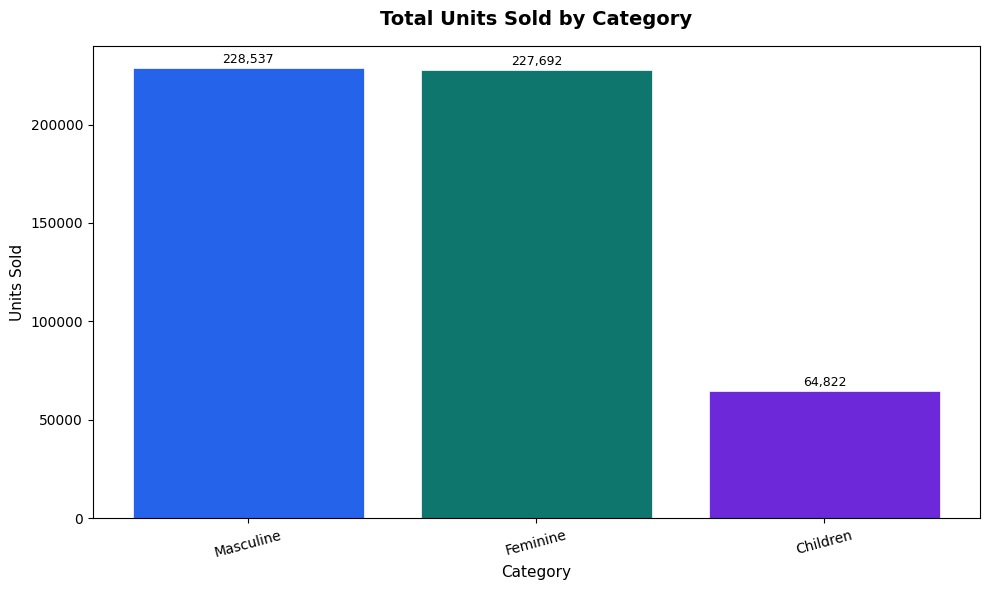

Saved!


In [26]:
# CELL 4 — Bar chart of sales by category
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2563eb","#0f766e","#6d28d9","#15803d","#c2410c","#854d0e"]
bars = ax.bar(
category_sales["Category"],
category_sales["Quantity"],
color=colors[:len(category_sales)],
edgecolor="white",
linewidth=0.5
)
ax.set_title("Total Units Sold by Category",
fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Category", fontsize=11)
ax.set_ylabel("Units Sold", fontsize=11)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
bar.get_height() + 1000,
f"{bar.get_height():,.0f}",
ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("sales_by_category.png", dpi=150,
bbox_inches="tight")
plt.show()
print("Saved!")

In [27]:
# CELL 5 — Simple Demand Forecast
# We use average sales per category to forecast
# This works even without proper date column
# Calculate average monthly demand per category
# Assuming data covers ~36 months (3 years)
MONTHS_IN_DATA = 36
FORECAST_MONTHS = 6
forecast_data = category_sales.copy()
forecast_data["Avg Monthly Units"] = (
forecast_data["Quantity"] / MONTHS_IN_DATA
).round(0)
# Simple forecast with 5% growth assumption
forecast_data["Forecast Next 6 Months"] = (
forecast_data["Avg Monthly Units"] * FORECAST_MONTHS * 1.05
).round(0)
print("Demand Forecast Summary:")
print(forecast_data[["Category",
"Avg Monthly Units",
"Forecast Next 6 Months"]].to_string(index=False))

Demand Forecast Summary:
 Category  Avg Monthly Units  Forecast Next 6 Months
Masculine             6348.0                 39992.0
 Feminine             6325.0                 39848.0
 Children             1801.0                 11346.0


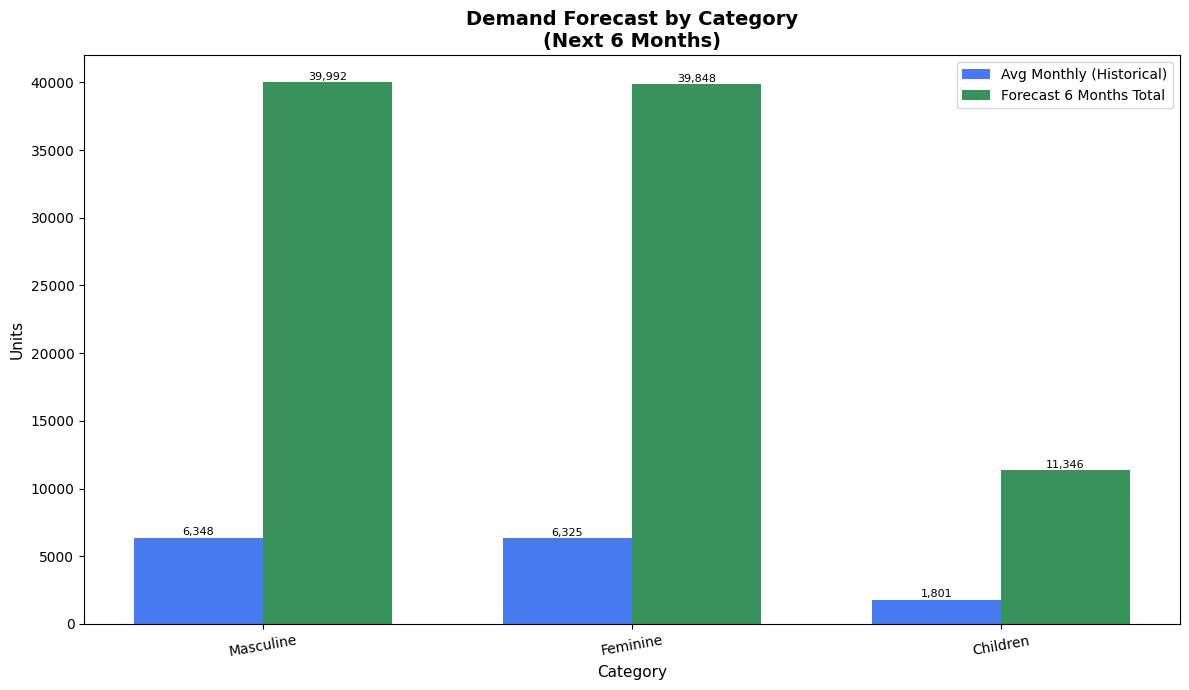

Saved as demand_forecast.png


In [30]:
# CELL 6 — Forecast visualization
categories = forecast_data["Category"].tolist()
avg_monthly = forecast_data["Avg Monthly Units"].tolist()
forecast_6m = forecast_data["Forecast Next 6 Months"].tolist()
x = np.arange(len(categories))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, avg_monthly, width,
label="Avg Monthly (Historical)",
color="#2563eb", alpha=0.85)
bars2 = ax.bar(x + width/2, forecast_6m, width,
label="Forecast 6 Months Total",
color="#15803d", alpha=0.85)
ax.set_title("Demand Forecast by Category\n(Next 6 Months)",
fontsize=14, fontweight="bold")
ax.set_xlabel("Category", fontsize=11)
ax.set_ylabel("Units", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=10)
ax.legend(fontsize=10)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2,
bar.get_height()+50,
f"{bar.get_height():,.0f}",
ha="center",va="bottom",fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2,
bar.get_height()+50,
f"{bar.get_height():,.0f}",
ha="center",va="bottom",fontsize=8)
plt.tight_layout()
plt.savefig("demand_forecast.png", dpi=150,
bbox_inches="tight")
plt.show()
print("Saved as demand_forecast.png")

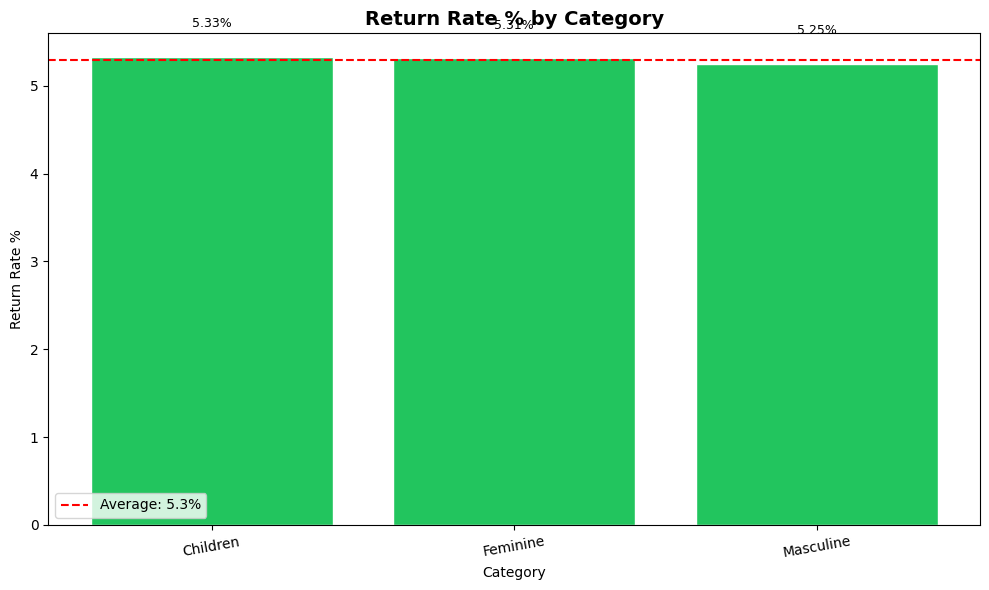

Saved!


In [35]:
# CELL 7 — Return rate per category
# Calculate return rate per category
category_stats = df.groupby("Category").agg(
total=("Quantity","count"),
returns=("is_return","sum") if "is_return" in df.columns
else ("Transaction Type",
lambda x: (x=="Return").sum())
).reset_index()
if "is_return" not in df.columns:
    df_tmp = df.copy()
    df_tmp["is_ret"] = (df_tmp["Transaction Type"]=="Return").astype(int)
category_stats = df_tmp.groupby("Category").agg(
total=("Quantity","count"),
returns=("is_ret","sum")
).reset_index()
category_stats["return_rate"] = (
category_stats["returns"] /
category_stats["total"] * 100
).round(2)
fig, ax = plt.subplots(figsize=(10, 6))
colors_ret = ["#dc2626" if r > 20 else "#f97316"
if r > 15 else "#22c55e"
for r in category_stats["return_rate"]]
bars = ax.bar(category_stats["Category"],
category_stats["return_rate"],
color=colors_ret, edgecolor="white")
ax.set_title("Return Rate % by Category",
fontsize=14, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Return Rate %")
ax.axhline(y=category_stats["return_rate"].mean(),
color="red", linestyle="--",
label=f"Average: {category_stats['return_rate'].mean():.1f}%")
ax.legend()
for bar, rate in zip(bars, category_stats["return_rate"]):
    ax.text(bar.get_x()+bar.get_width()/2,
bar.get_height()+0.3,
f"{rate}%", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("return_rate_category.png", dpi=150,
bbox_inches="tight")
plt.show()
print("Saved!")